### Import Library

Tahap ini berisi proses pemanggilan sejumlah library yang diperlukan untuk mendukung pengolahan citra digital, ekstraksi fitur tekstur, visualisasi data, pengelolaan data, serta proses pelatihan dan evaluasi model klasifikasi. Setiap library memiliki fungsi tertentu yang berperan dalam mendukung keseluruhan tahapan penelitian.

| No | Library                                    | Fungsi                                                                                                                                                                                                   |
| -- | ------------------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1  | `os`                                       | Digunakan untuk mengakses dan mengelola sistem operasi, seperti membaca direktori dataset, menelusuri struktur folder, serta menangani file citra yang digunakan dalam penelitian.                       |
| 2  | `cv2` (`cv`)                               | Merupakan library OpenCV yang digunakan untuk melakukan berbagai proses pengolahan citra digital, seperti membaca citra, mengubah ukuran gambar, konversi ke grayscale, filtering, dan manipulasi citra. |
| 3  | `zipfile`                                  | Digunakan untuk mengekstrak dataset yang masih berbentuk file `.zip` agar dapat diakses dan diproses pada tahap analisis selanjutnya.                                                                    |
| 4  | `numpy` (`np`)                             | Digunakan untuk melakukan komputasi numerik serta mengolah data dalam bentuk array multidimensi, terutama pada proses pengolahan citra dan perhitungan matematis.                                        |
| 5  | `pandas` (`pd`)                            | Digunakan untuk mengelola data dalam bentuk tabel atau `DataFrame`, seperti menyusun hasil ekstraksi fitur, menyimpan data fitur, serta menampilkan hasil evaluasi model.                                |
| 6  | `matplotlib.pyplot` (`plt`)                | Digunakan untuk membuat visualisasi, misalnya menampilkan sampel citra, distribusi data, grafik hasil analisis, serta confusion matrix dari hasil klasifikasi.                                           |
| 7  | `skimage.feature.graycomatrix`             | Digunakan untuk membentuk Gray Level Co-occurrence Matrix (GLCM), yaitu matriks yang merepresentasikan hubungan tingkat keabuan antar piksel dalam citra.                                                |
| 8  | `skimage.feature.graycoprops`              | Digunakan untuk menghitung fitur tekstur berdasarkan matriks GLCM, seperti contrast, dissimilarity, homogeneity, energy, correlation, dan ASM.                                                           |
| 9  | `sklearn.model_selection.train_test_split` | Digunakan untuk membagi dataset menjadi data latih dan data uji sehingga model dapat dilatih serta dievaluasi menggunakan data yang berbeda.                                                             |
| 10 | `sklearn.preprocessing.LabelEncoder`       | Digunakan untuk mengubah label kelas berbentuk teks menjadi nilai numerik agar dapat diproses oleh algoritma machine learning.                                                                           |
| 11 | `sklearn.preprocessing.StandardScaler`     | Digunakan untuk menstandarkan skala data fitur agar setiap fitur memiliki rentang nilai yang seimbang dan tidak mendominasi proses pembelajaran model.                                                   |
| 12 | `sklearn.metrics.accuracy_score`           | Digunakan untuk menghitung nilai akurasi model berdasarkan perbandingan antara jumlah prediksi yang benar dengan keseluruhan data uji.                                                                   |
| 13 | `sklearn.metrics.classification_report`    | Digunakan untuk menampilkan laporan evaluasi model yang mencakup nilai precision, recall, f1-score, dan support untuk setiap kelas.                                                                      |
| 14 | `sklearn.metrics.confusion_matrix`         | Digunakan untuk menyajikan matriks evaluasi yang menunjukkan jumlah prediksi benar dan salah pada masing-masing kelas.                                                                                   |
| 15 | `sklearn.metrics.precision_score`          | Digunakan untuk mengukur tingkat ketepatan model dalam memprediksi suatu kelas berdasarkan hasil klasifikasi yang diberikan.                                                                             |
| 16 | `sklearn.metrics.recall_score`             | Digunakan untuk mengukur kemampuan model dalam mengenali seluruh data yang benar pada setiap kelas.                                                                                                      |
| 17 | `sklearn.metrics.f1_score`                 | Digunakan untuk menghitung nilai evaluasi yang menyeimbangkan precision dan recall melalui rata-rata harmonis keduanya.                                                                                  |
| 18 | `sklearn.svm.SVC`                          | Digunakan sebagai implementasi algoritma Support Vector Machine (SVM), yaitu metode klasifikasi yang bekerja dengan mencari hyperplane terbaik untuk memisahkan kelas data.                              |
| 19 | `sklearn.ensemble.RandomForestClassifier`  | Digunakan sebagai implementasi algoritma Random Forest yang membangun sejumlah decision tree untuk meningkatkan stabilitas, generalisasi, dan performa klasifikasi.                                      |
| 20 | `sklearn.neighbors.KNeighborsClassifier`   | Digunakan sebagai implementasi algoritma K-Nearest Neighbors (KNN), yaitu metode klasifikasi yang menentukan kelas data berdasarkan kedekatannya dengan sejumlah tetangga terdekat.                      |

Berdasarkan library yang digunakan, penelitian ini menggabungkan beberapa tahapan utama, yaitu pengolahan citra digital menggunakan OpenCV, ekstraksi fitur tekstur menggunakan metode Gray Level Co-occurrence Matrix (GLCM), serta klasifikasi menggunakan tiga algoritma machine learning, yaitu K-Nearest Neighbors (KNN), Support Vector Machine (SVM), dan Random Forest. Kombinasi tersebut digunakan untuk mengklasifikasikan tingkat kematangan biji kopi serta membandingkan performa masing-masing model berdasarkan hasil evaluasi yang diperoleh.


In [117]:
import os
import cv2 as cv
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [118]:
import zipfile

zip_path = '/content/archive.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"'{zip_path}' extracted to '{extract_path}'")

'/content/archive.zip' extracted to '/content/'


In [119]:
dataset_path = "/content/train"
class_names = [
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

In [120]:
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png')

def load_dataset(dataset_path: str, class_names: list) -> tuple:
    data       = []
    labels     = []
    file_names = []

    print(f"Memuat dataset dari: {dataset_path}")
    print(f"Kelas ditemukan    : {class_names}\n")

    for class_name in class_names:
        class_path   = os.path.join(dataset_path, class_name)
        image_files  = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(VALID_EXTENSIONS)
        ]

        loaded  = 0
        skipped = 0

        for filename in image_files:
            image_path = os.path.join(class_path, filename)
            image      = cv.imread(image_path)

            if image is None:
                skipped += 1
                continue

            data.append(image)
            labels.append(class_name)
            file_names.append(filename)
            loaded += 1

        print(f"  [{class_name}] dimuat: {loaded} gambar | dilewati: {skipped} gambar")

    print(f"\nTotal gambar berhasil dimuat: {len(data)}")
    return data, labels, file_names

data, labels, file_names = load_dataset(dataset_path, class_names)
print("Jumlah data:", len(data))
print("Jumlah label:", len(labels))
print("Jumlah nama file:", len(file_names))

Memuat dataset dari: /content/train
Kelas ditemukan    : ['Green', 'Light', 'Dark', 'Medium']

  [Green] dimuat: 300 gambar | dilewati: 0 gambar
  [Light] dimuat: 300 gambar | dilewati: 0 gambar
  [Dark] dimuat: 300 gambar | dilewati: 0 gambar
  [Medium] dimuat: 300 gambar | dilewati: 0 gambar

Total gambar berhasil dimuat: 1200
Jumlah data: 1200
Jumlah label: 1200
Jumlah nama file: 1200


In [121]:
def hitung_jumlah_data(dataset_path):
    """
    Menghitung jumlah citra pada setiap kelas dalam dataset.
    Label kelas diambil dari nama folder.
    """

    jumlah_data = {}

    class_names = [
        folder for folder in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, folder))
    ]

    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)

        image_files = [
            file for file in os.listdir(class_path)
            if file.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        jumlah_data[class_name] = len(image_files)

    jumlah_df = pd.DataFrame({
        "Kelas": list(jumlah_data.keys()),
        "Jumlah Data": list(jumlah_data.values())
    })

    return jumlah_df

In [122]:
jumlah_df = hitung_jumlah_data(dataset_path)
jumlah_df

,Kelas,Jumlah Data
0,Green,300
1,Light,300
2,Dark,300
3,Medium,300


### Menghitung Jumlah Data pada Setiap Kelas

Fungsi `hitung_jumlah_data(dataset_path)` digunakan untuk menghitung jumlah citra pada setiap kelas dalam dataset. Nama kelas diperoleh dari nama folder yang terdapat pada direktori dataset. Selanjutnya, program membaca seluruh file gambar dengan ekstensi `.jpg`, `.jpeg`, dan `.png` pada setiap folder, kemudian menghitung jumlah gambar yang ditemukan menggunakan fungsi `len()`.

Hasil perhitungan disimpan dalam bentuk `DataFrame` yang terdiri dari kolom `Kelas` dan `Jumlah Data`. Informasi ini digunakan untuk mengetahui distribusi data pada setiap kategori tingkat kematangan biji kopi dan memastikan bahwa jumlah data antar kelas relatif seimbang sebelum dilakukan proses klasifikasi.


In [123]:
def visualisasi_distribusi_data(jumlah_df, title):
    """
    Menampilkan grafik distribusi jumlah data setiap kelas.
    """

    plt.figure(figsize=(10, 5))
    plt.bar(jumlah_df["Kelas"], jumlah_df["Jumlah Data"])

    plt.title(title)
    plt.xlabel("Kelas")
    plt.ylabel("Jumlah Citra")
    plt.xticks(rotation=30)
    plt.show()

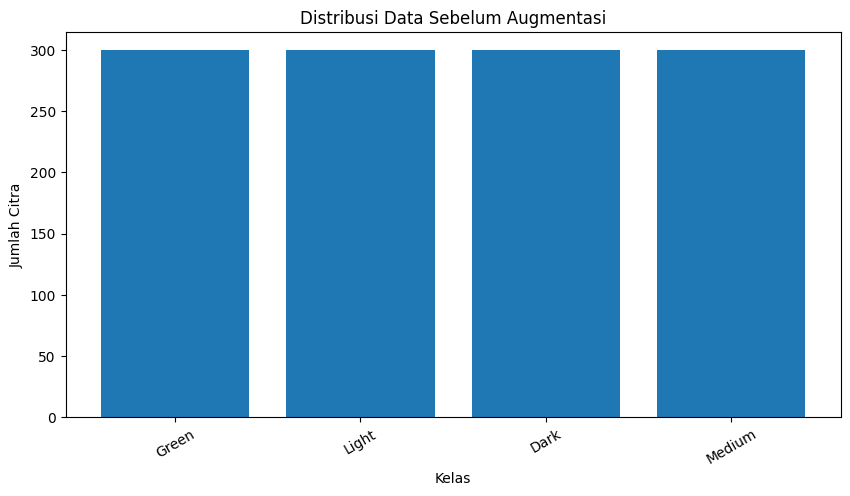

In [124]:
visualisasi_distribusi_data(
    jumlah_df,
    "Distribusi Data Sebelum Augmentasi"
)

### Visualisasi Distribusi Data

Fungsi `visualisasi_distribusi_data(jumlah_df, title)` digunakan untuk menampilkan grafik batang (*bar chart*) yang menunjukkan distribusi jumlah citra pada setiap kelas dalam dataset. Grafik dibuat menggunakan library Matplotlib dengan sumbu horizontal (x) yang merepresentasikan nama kelas dan sumbu vertikal (y) yang menunjukkan jumlah citra pada masing-masing kelas.

Pada pemanggilan fungsi `visualisasi_distribusi_data(jumlah_df, "Distribusi Data Sebelum Augmentasi")`, grafik yang dihasilkan menampilkan distribusi data sebelum dilakukan proses augmentasi. Visualisasi ini bertujuan untuk memberikan gambaran mengenai persebaran jumlah data pada setiap kategori tingkat kematangan biji kopi serta membantu mengidentifikasi apakah terdapat ketidakseimbangan jumlah data antar kelas yang berpotensi memengaruhi performa model klasifikasi.


### Menampilkan Sampel Data

Fungsi `tampilkan_sample_data()` digunakan untuk menampilkan satu sampel gambar dari setiap kelas dalam dataset. Program terlebih dahulu membaca seluruh folder kelas dan mengambil satu file gambar dari masing-masing folder yang memiliki ekstensi `.jpg`, `.jpeg`, atau `.png`.

Setiap gambar kemudian dibaca menggunakan OpenCV dan dikonversi dari format warna BGR ke RGB agar dapat ditampilkan dengan benar menggunakan Matplotlib. Selanjutnya, seluruh gambar sampel ditampilkan dalam satu figure beserta nama kelasnya, sedangkan sumbu koordinat disembunyikan agar tampilan lebih jelas.

Visualisasi ini bertujuan untuk memberikan gambaran awal mengenai karakteristik visual pada setiap kategori tingkat kematangan biji kopi serta memastikan bahwa data citra berhasil dimuat dengan baik sebelum dilakukan tahap preprocessing dan ekstraksi fitur.


In [125]:
def tampilkan_sample_data(dataset_path: str, class_names: list, figsize: tuple = (14, 5)) -> None:
    """
    Menampilkan 1 sampel gambar dari setiap kelas dalam dataset.

    Args:
        dataset_path (str)  : Path folder utama dataset
        class_names  (list) : Daftar nama kelas (nama folder)
        figsize      (tuple): Ukuran figure matplotlib, default (14, 5)
    """
    plt.figure(figsize=figsize)

    for i, class_name in enumerate(class_names):
        class_path  = os.path.join(dataset_path, class_name)
        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(VALID_EXTENSIONS)
        ]

        if len(image_files) == 0:
            print(f"[PERINGATAN] Tidak ada gambar pada kelas '{class_name}'")
            continue

        image_path = os.path.join(class_path, image_files[0])

        image     = cv.imread(image_path)
        image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

        plt.subplot(1, len(class_names), i + 1)
        plt.imshow(image_rgb)
        plt.title(class_name)
        plt.axis("off")

    plt.suptitle("Sampel Gambar per Kelas", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


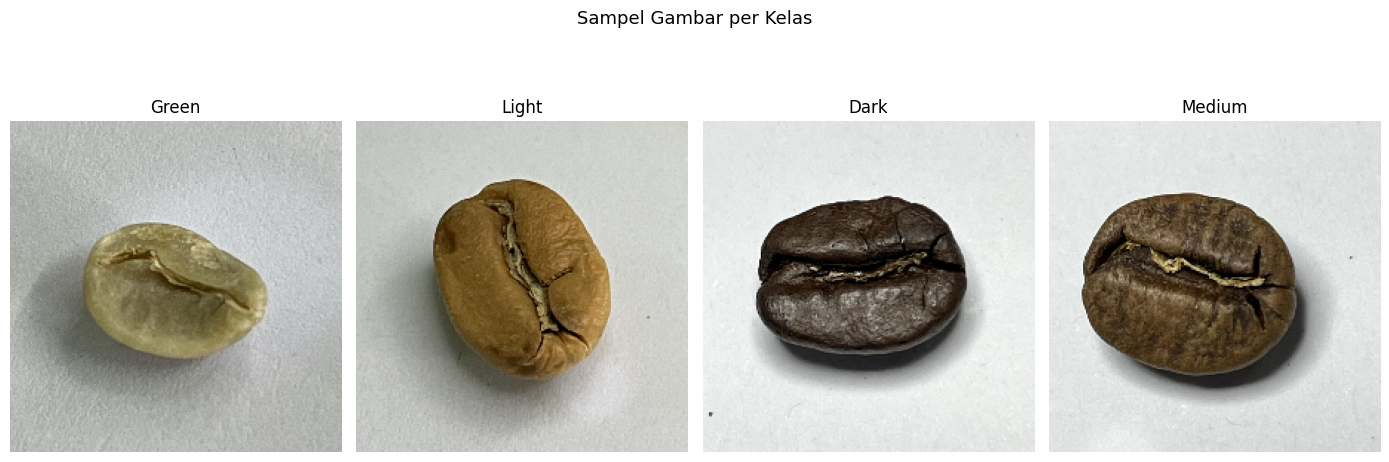

In [126]:
tampilkan_sample_data(dataset_path, class_names)

### Preprocessing Citra

Fungsi `preprocess_image()` digunakan untuk melakukan tahap awal preprocessing pada citra sebelum masuk ke proses ekstraksi fitur atau klasifikasi. Pada kode ini, preprocessing terdiri dari empat tahap utama, yaitu resize, konversi grayscale, mean filter, dan morphological closing.

Tahap pertama dilakukan oleh fungsi `prepro1()`, yaitu mengubah ukuran citra menjadi `128 × 128` piksel menggunakan metode nearest neighbor. Metode ini bekerja dengan mengambil nilai piksel terdekat dari citra asli untuk mengisi piksel pada citra baru. Resize dilakukan agar seluruh citra memiliki ukuran yang seragam sehingga lebih mudah diproses pada tahap berikutnya.

Tahap kedua dilakukan oleh fungsi `prepro2()`, yaitu mengubah citra berwarna menjadi citra grayscale. Proses ini menggunakan rumus luminance dengan memperhitungkan bobot kanal merah, hijau, dan biru. Karena citra yang dibaca menggunakan OpenCV umumnya berada dalam format BGR, maka kanal `image[:, :, 2]` digunakan sebagai merah, `image[:, :, 1]` sebagai hijau, dan `image[:, :, 0]` sebagai biru.

Tahap ketiga dilakukan oleh fungsi `prepro6()`, yaitu mean filter dengan kernel `3 × 3`. Filter ini bekerja dengan mengganti setiap nilai piksel menggunakan rata-rata dari piksel-piksel tetangganya. Mean filter digunakan untuk menghaluskan noise ringan pada citra sehingga distribusi intensitas menjadi lebih merata dan stabil sebelum proses ekstraksi fitur.

Tahap keempat dilakukan oleh fungsi `prepro7()`, yaitu morphological closing grayscale. Closing merupakan kombinasi dari operasi dilasi diikuti oleh erosi menggunakan kernel `3 × 3`. Dilasi bekerja dengan mengambil nilai maksimum pada area kernel, sedangkan erosi mengambil nilai minimum. Proses closing berfungsi untuk menutup celah kecil atau lubang pada citra serta memperhalus kontur objek tanpa mengubah ukuran keseluruhannya secara signifikan.

Hasil akhir dari fungsi `preprocess_image()` adalah citra grayscale berukuran `128 × 128` piksel yang telah melalui proses penghalusan dan perbaikan morfologi. Tahap ini bertujuan untuk menyeragamkan ukuran citra, menyederhanakan informasi warna, serta meningkatkan kualitas tekstur agar data lebih siap digunakan dalam proses analisis citra.

In [127]:
def prepro1(image):
    """
    Preprocessing 1: Resize.
    Mengubah ukuran citra menjadi 128 × 128 piksel
    menggunakan metode nearest neighbor sederhana.
    """
    h, w = image.shape[:2]
    new_h, new_w = 128, 128

    resized = np.zeros((new_h, new_w, image.shape[2]), dtype=image.dtype)

    for i in range(new_h):
        for j in range(new_w):
            x = int(i * h / new_h)
            y = int(j * w / new_w)
            resized[i, j] = image[x, y]

    return resized


def prepro2(image):
    """
    Preprocessing 2: Grayscale.
    Mengubah citra RGB menjadi citra keabuan
    menggunakan persamaan luminance.
    """
    gray = (
        0.299 * image[:, :, 2] +
        0.587 * image[:, :, 1] +
        0.114 * image[:, :, 0]
    ).astype(np.uint8)

    return gray


def prepro3(image):
    """
    Preprocessing 3: Median Filter.
    Mengurangi noise dengan mengganti nilai piksel
    menggunakan median dari tetangga 5 × 5.
    """
    pad = 2
    padded = np.pad(image, pad, mode='edge')
    median = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+5, j:j+5]
            median[i, j] = np.median(window)

    return median


def prepro4(image):
    """
    Gaussian Filter manual menggunakan kernel 3 × 3.
    Berfungsi menghaluskan citra dan mengurangi noise.
    """
    kernel = np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ]) / 16

    padded = np.pad(image, 1, mode='edge')
    gaussian = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+3, j:j+3]
            gaussian[i, j] = np.sum(window * kernel)

    return gaussian.astype(np.uint8)


def prepro5(image, alpha=0.2):
    # [PERUBAHAN] Mengubah citra ke float agar perhitungan lebih aman
    img = image.astype(np.float32)

    # [PERUBAHAN] Kernel Sobel arah X
    kernel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float32)

    # [PERUBAHAN] Kernel Sobel arah Y
    kernel_y = np.array([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ], dtype=np.float32)

    tinggi, lebar = img.shape
    pad = 1
    padded = np.pad(img, ((pad, pad), (pad, pad)), mode="edge")

    sobel_x = np.zeros_like(img)
    sobel_y = np.zeros_like(img)

    for i in range(tinggi):
        for j in range(lebar):
            area = padded[i:i + 3, j:j + 3]
            sobel_x[i, j] = np.sum(area * kernel_x)
            sobel_y[i, j] = np.sum(area * kernel_y)

    # [PERUBAHAN] Menghitung besar tepi dari arah X dan Y
    sobel_magnitude = np.sqrt((sobel_x ** 2) + (sobel_y ** 2))

    # [PERUBAHAN] Normalisasi nilai Sobel ke rentang 0-255
    if np.max(sobel_magnitude) != 0:
        sobel_magnitude = sobel_magnitude / np.max(sobel_magnitude) * 255

    # [PERUBAHAN] Menggabungkan citra hasil Gaussian dengan informasi tepi Sobel
    enhanced = img + (alpha * sobel_magnitude)

    enhanced = np.clip(enhanced, 0, 255)

    return enhanced.astype(np.uint8)

def prepro6(image, kernel_size=3):
    # [PERUBAHAN] Mean filter digunakan untuk menghaluskan noise ringan
    pad = kernel_size // 2
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode="edge")

    hasil = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            area = padded[i:i + kernel_size, j:j + kernel_size]
            hasil[i, j] = np.mean(area)

    return hasil.astype(np.uint8)


def dilasi_grayscale(image, kernel_size=3):
    # [PERUBAHAN] Dilasi grayscale mengambil nilai maksimum pada area kernel
    pad = kernel_size // 2
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode="edge")

    hasil = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            area = padded[i:i + kernel_size, j:j + kernel_size]
            hasil[i, j] = np.max(area)

    return hasil.astype(np.uint8)


def erosi_grayscale(image, kernel_size=3):
    # [PERUBAHAN] Erosi grayscale mengambil nilai minimum pada area kernel
    pad = kernel_size // 2
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode="edge")

    hasil = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            area = padded[i:i + kernel_size, j:j + kernel_size]
            hasil[i, j] = np.min(area)

    return hasil.astype(np.uint8)


def prepro7(image, kernel_size=3):
    # [PERUBAHAN] Closing = dilasi lalu erosi
    image = dilasi_grayscale(image, kernel_size)
    image = erosi_grayscale(image, kernel_size)

    return image


In [128]:
def preprocess_image(image):
    """
    Melakukan preprocessing pada satu gambar untuk Percobaan 3.

    Tahapan:
        1. Resize
        2. Grayscale

    """
    image = prepro1(image)          # Resize
    image = prepro2(image)          # Grayscale
    image = prepro6(image, 3)       # [PERUBAHAN] Filtering rata-rata (Mean)
    image = prepro7(image, 3)       # [PERUBAHAN] Morfologi grayscale closing


    return image

In [129]:
data_preprocessed = [preprocess_image(img) for img in data]

print(f"Preprocessing selesai.")
print(f"Jumlah gambar : {len(data_preprocessed)}")
print(f"Ukuran output : {data_preprocessed[0].shape}  → (tinggi, lebar)")

Preprocessing selesai.
Jumlah gambar : 1200
Ukuran output : (128, 128)  → (tinggi, lebar)


### Menjalankan Preprocessing pada Seluruh Data

Kode `data_preprocessed = [preprocess_image(img) for img in data]` digunakan untuk menerapkan fungsi preprocessing ke seluruh gambar yang ada di dalam variabel `data`. Setiap gambar akan diproses satu per satu melalui fungsi `preprocess_image()`, sehingga seluruh citra mengalami tahapan resize dan konversi grayscale.

Hasil dari proses tersebut disimpan dalam variabel `data_preprocessed` dalam bentuk list. Dengan demikian, `data_preprocessed` berisi kumpulan gambar yang sudah memiliki format seragam, yaitu citra grayscale berukuran `128 × 128` piksel.

Bagian `print()` digunakan untuk menampilkan informasi hasil preprocessing. Program akan mencetak bahwa proses preprocessing telah selesai, jumlah gambar yang berhasil diproses, serta ukuran output dari gambar pertama. Informasi ukuran output ditampilkan untuk memastikan bahwa hasil preprocessing sudah sesuai, yaitu berbentuk `(tinggi, lebar)`.

### Menampilkan Perbandingan Citra Original dan Hasil Preprocessing

Kode ini digunakan untuk menampilkan perbandingan antara citra asli dan citra hasil preprocessing dari setiap kelas dalam dataset. Program terlebih dahulu membuat figure berukuran `8 × 8`, kemudian melakukan perulangan berdasarkan daftar kelas yang terdapat pada variabel `class_names`.

Pada setiap kelas, program mengambil folder kelas menggunakan `os.path.join()`, lalu memilih file gambar pertama yang memiliki ekstensi `.jpg`, `.jpeg`, atau `.png`. Gambar tersebut kemudian dibaca menggunakan `cv.imread()` dan diproses menggunakan fungsi `preprocess_image()`, sehingga menghasilkan citra yang sudah melalui tahap resize dan grayscale.

Hasil visualisasi ditampilkan dalam bentuk subplot dengan dua kolom. Kolom pertama menampilkan gambar asli dalam format RGB, sedangkan kolom kedua menampilkan hasil preprocessing berupa citra grayscale yang telah di-resize. Visualisasi ini bertujuan untuk melihat perbedaan antara citra awal dan citra setelah preprocessing, sekaligus memastikan bahwa proses grayscale dan resize berhasil diterapkan dengan benar pada setiap kelas.


### Analisis Hasil Preprocessing

Berdasarkan hasil visualisasi, proses preprocessing berhasil diterapkan pada citra biji kopi untuk klasifikasi tingkat kematangan, yaitu kelas `Green`, `Light`, `Medium`, dan `Dark`. Setiap citra original diubah melalui empat tahap, yaitu resize, grayscale, mean filter, dan morphological closing.

Tahap resize membuat seluruh gambar memiliki ukuran yang seragam (`128 × 128` piksel), sedangkan tahap grayscale mengubah citra berwarna menjadi citra keabuan sehingga fokus analisis beralih ke pola intensitas dan tekstur permukaan. Kedua tahap ini merupakan dasar sebelum dilakukan ekstraksi fitur GLCM.

Tahap mean filter kemudian diterapkan untuk menghaluskan noise ringan pada citra. Filter ini menggantikan setiap piksel dengan rata-rata tetangganya menggunakan kernel `3 × 3`, sehingga distribusi intensitas menjadi lebih merata. Hal ini penting karena GLCM sangat sensitif terhadap perubahan nilai piksel, dan noise yang tidak dihilangkan dapat menghasilkan fitur tekstur yang kurang representatif.

Tahap terakhir, yaitu morphological closing, berfungsi untuk menutup celah atau lubang kecil pada citra serta memperhalus kontur objek. Operasi ini dilakukan dengan dilasi diikuti erosi menggunakan kernel `3 × 3`. Hasilnya, permukaan biji kopi tampak lebih rapi dan kontur tepinya lebih konsisten antar gambar.

Hasil akhir preprocessing menunjukkan bahwa bentuk biji kopi, garis tengah biji, serta pola tekstur permukaan masih dapat terlihat dengan jelas. Dibandingkan hanya menggunakan resize dan grayscale, penambahan mean filter dan closing membuat citra tampak lebih halus dan bersih. Perbedaan antar kelas kematangan juga terlihat lebih konsisten, yang diharapkan dapat membantu model mengenali karakteristik visual dari setiap tingkat kematangan biji kopi dengan lebih baik.

Namun, penggunaan grayscale tetap memiliki kelemahan karena warna asli biji kopi dihilangkan. Padahal, warna merupakan salah satu ciri utama dalam membedakan tingkat kematangan biji kopi, terutama antara kelas `Green`, `Light`, dan `Medium`. Setelah diubah menjadi grayscale, beberapa kelas dapat terlihat lebih mirip karena perbedaan warna tidak lagi terlihat secara langsung. Preprocessing tambahan berupa mean filter dan closing membantu memperbaiki kondisi ini dari sisi tekstur, tetapi tidak dapat sepenuhnya menggantikan informasi warna yang hilang.

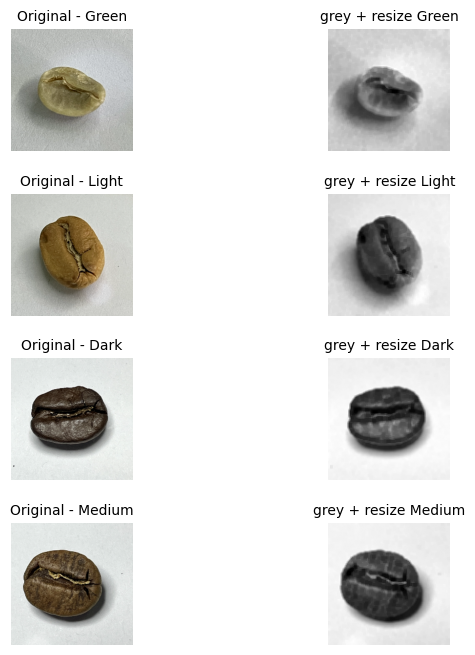

In [130]:
plt.figure(figsize=(8, 8))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    image_path = os.path.join(class_path, image_files[0])

    image = cv.imread(image_path)
    processed = preprocess_image(image)

    plt.subplot(len(class_names), 2, (i * 2) + 1)
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.title(f"Original - {class_name}", fontsize=10)
    plt.axis("off")

    plt.subplot(len(class_names), 2, (i * 2) + 2)
    plt.imshow(processed, cmap="gray")
    plt.title(f"grey + resize {class_name}", fontsize=10)
    plt.axis("off")

plt.subplots_adjust(wspace=0.05, hspace=0.35)
plt.show()

In [131]:

DISTANCES   = [1, 2, 3, 4, 5]
ANGLES      = [0, np.pi/4, np.pi/2, 3*np.pi/4]
ANGLE_NAMES = ["0", "45", "90", "135"]
PROPERTIES  = [
    "contrast", "dissimilarity", "homogeneity",
    "energy", "correlation", "ASM"
]


def extract_glcm_features(image: np.ndarray) -> dict:
    """
    Ekstraksi fitur tekstur GLCM dari satu gambar grayscale.

    Menggunakan 5 jarak (1–5), 4 sudut (0°/45°/90°/135°),
    dan 7 properti: contrast, dissimilarity, homogeneity,
    energy, correlation, ASM, dan entropy (manual).

    Args:
        image (np.ndarray): Gambar grayscale 2D hasil preprocessing

    Returns:
        dict: 140 fitur dengan nama format {properti}_d{jarak}_a{sudut}
    """
    glcm = graycomatrix(
        image,
        distances=DISTANCES,
        angles=ANGLES,
        levels=256,
        symmetric=True,
        normed=True
    )

    features = {}

    for prop in PROPERTIES:
        values = graycoprops(glcm, prop)
        for d_idx, dist in enumerate(DISTANCES):
            for a_idx, angle in enumerate(ANGLE_NAMES):
                features[f"{prop}_d{dist}_a{angle}"] = values[d_idx, a_idx]

    # Entropy dihitung manual (tidak tersedia di graycoprops)
    for d_idx, dist in enumerate(DISTANCES):
        for a_idx, angle in enumerate(ANGLE_NAMES):
            matrix = glcm[:, :, d_idx, a_idx]
            features[f"entropy_d{dist}_a{angle}"] = (
                -np.sum(matrix * np.log2(matrix + 1e-10))
            )

    return features

### Ekstraksi Fitur GLCM

Kode ini digunakan untuk mengekstraksi fitur tekstur dari citra grayscale menggunakan metode **GLCM** atau *Gray Level Co-occurrence Matrix*. GLCM bekerja dengan menghitung hubungan kemunculan pasangan piksel berdasarkan jarak dan arah tertentu. Pada kode ini, jarak yang digunakan adalah `1, 2, 3, 4, 5`, sedangkan sudut yang digunakan adalah `0°`, `45°`, `90°`, dan `135°`.

Fungsi `extract_glcm_features()` menerima input berupa citra grayscale hasil preprocessing. Citra tersebut kemudian diproses menggunakan `graycomatrix()` dengan `levels=256`, sehingga nilai intensitas piksel dianggap berada pada rentang `0–255`. Parameter `symmetric=True` membuat hubungan antar piksel dihitung secara dua arah, sedangkan `normed=True` membuat nilai matriks dinormalisasi agar berbentuk probabilitas.

Setelah matriks GLCM terbentuk, kode menghitung beberapa fitur tekstur menggunakan `graycoprops()`, yaitu `contrast`, `dissimilarity`, `homogeneity`, `energy`, `correlation`, dan `ASM`. Setiap fitur dihitung untuk semua kombinasi jarak dan sudut, lalu disimpan ke dalam dictionary dengan format nama seperti `contrast_d1_a0`, `homogeneity_d3_a90`, dan seterusnya.

Selain fitur dari `graycoprops()`, kode juga menghitung fitur `entropy` secara manual karena entropy tidak tersedia langsung pada fungsi tersebut. Entropy digunakan untuk mengukur tingkat ketidakteraturan tekstur pada citra. Semakin tinggi nilai entropy, semakin kompleks atau tidak beraturan tekstur citra tersebut.

Secara keseluruhan, fungsi ini menghasilkan `140 fitur`, yang berasal dari `7 properti × 5 jarak × 4 sudut`. Fitur-fitur ini kemudian dapat digunakan sebagai data numerik untuk proses klasifikasi tingkat kematangan biji kopi.

### Ekstraksi Fitur GLCM

Kode ini digunakan untuk melakukan ekstraksi fitur tekstur pada seluruh citra hasil preprocessing. Setiap gambar yang tersimpan dalam `data_preprocessed` diproses menggunakan fungsi `extract_glcm_features()` untuk menghasilkan fitur GLCM berdasarkan variasi jarak dan sudut tertentu.

Pada setiap perulangan, fitur yang telah diperoleh kemudian ditambahkan dengan informasi `Label` dan `Filename`. Kolom `Label` digunakan untuk menunjukkan kelas tingkat kematangan biji kopi, seperti `Green`, `Light`, `Medium`, dan `Dark`, sedangkan kolom `Filename` digunakan untuk menyimpan nama file gambar asal agar data tetap dapat dilacak.

Hasil ekstraksi fitur disimpan dalam list `hasil_fitur`, kemudian diubah menjadi DataFrame menggunakan `pd.DataFrame()`. Berdasarkan output, setiap baris merepresentasikan satu gambar, sedangkan setiap kolom merepresentasikan fitur tekstur yang dihasilkan, seperti `contrast` dan `entropy` pada beberapa jarak serta sudut. Total terdapat `142` kolom, yang terdiri dari fitur GLCM serta kolom tambahan `Label` dan `Filename`.

Secara umum, hasil ini menunjukkan bahwa citra biji kopi telah berhasil diubah dari bentuk gambar menjadi data numerik. Data numerik inilah yang nantinya digunakan sebagai input pada proses klasifikasi tingkat kematangan biji kopi.

In [132]:
hasil_fitur = []

for i in range(len(data_preprocessed)):
    features = extract_glcm_features(data_preprocessed[i])

    features["Label"] = labels[i]
    features["Filename"] = file_names[i]

    hasil_fitur.append(features)

hasil_ekstrak = pd.DataFrame(hasil_fitur)

hasil_ekstrak.head()

,contrast_d1_a0,contrast_d1_a45,contrast_d1_a90,contrast_d1_a135,contrast_d2_a0,contrast_d2_a45,contrast_d2_a90,contrast_d2_a135,contrast_d3_a0,contrast_d3_a45,...,entropy_d4_a0,entropy_d4_a45,entropy_d4_a90,entropy_d4_a135,entropy_d5_a0,entropy_d5_a45,entropy_d5_a90,entropy_d5_a135,Label,Filename
0,9.583969,20.806312,16.548844,28.131688,30.725942,20.806312,53.527468,28.131688,59.414000,63.001827,...,10.812227,10.931250,10.922201,10.969350,10.943407,11.127509,11.091114,11.171055,Green,green (156).png
1,18.738374,43.606981,28.837106,46.338893,60.024120,43.606981,92.704799,46.338893,114.538562,134.007433,...,10.537756,10.789107,10.795686,10.706090,10.672579,10.986316,10.963956,10.880916,Green,green (82).png
2,31.953063,44.200508,20.061577,55.315333,108.006510,44.200508,68.476190,55.315333,207.561875,143.179831,...,11.254236,11.156786,10.983094,11.287975,11.415798,11.381925,11.147623,11.497570,Green,green (136).png
3,18.396592,49.502015,34.284264,51.039370,60.408482,49.502015,113.707031,51.039370,114.298437,154.002079,...,10.753964,10.917222,10.918943,10.937442,10.871494,11.070883,11.051820,11.089251,Green,green (227).png
4,25.072835,52.343109,33.598241,58.258293,80.825707,52.343109,105.872396,58.258293,151.804625,158.871063,...,10.987592,11.001372,10.946579,11.134346,11.146189,11.199294,11.081447,11.332818,Green,green (122).png


In [133]:
print("Jumlah data:", hasil_ekstrak.shape[0])
print("Jumlah kolom:", hasil_ekstrak.shape[1])

Jumlah data: 1200
Jumlah kolom: 142


### Mengecek Jumlah Data dan Kolom

Kode ini digunakan untuk menampilkan ukuran dari DataFrame `hasil_ekstrak` setelah proses ekstraksi fitur selesai dilakukan. Perintah `hasil_ekstrak.shape[0]` digunakan untuk menghitung jumlah baris data, sedangkan `hasil_ekstrak.shape[1]` digunakan untuk menghitung jumlah kolom.

Berdasarkan output, terdapat `1200` data citra yang berhasil diproses dan diekstraksi fiturnya. Setiap baris pada DataFrame merepresentasikan satu gambar biji kopi yang telah melalui tahap preprocessing dan ekstraksi fitur GLCM.

Jumlah kolom sebanyak `142` menunjukkan bahwa setiap citra memiliki banyak fitur numerik hasil ekstraksi, ditambah dengan kolom `Label` dan `Filename`. Data ini kemudian dapat digunakan sebagai dataset untuk proses klasifikasi tingkat kematangan biji kopi.

### Seleksi Fitur Berdasarkan Korelasi

Kode ini digunakan untuk melakukan seleksi fitur pada hasil ekstraksi GLCM. Kolom `Label` dan `Filename` terlebih dahulu dihapus karena keduanya bukan termasuk fitur numerik yang digunakan untuk proses klasifikasi. Setelah itu, program menghitung nilai korelasi antarfitur menggunakan `fitur.corr().abs()`.

Nilai korelasi yang digunakan adalah nilai absolut, sehingga hubungan positif maupun negatif yang sangat kuat tetap dianggap sebagai korelasi tinggi. Program kemudian mengambil bagian segitiga atas dari matriks korelasi menggunakan `np.triu()` agar pasangan fitur yang sama tidak dihitung dua kali.

Fitur yang memiliki korelasi lebih dari `0.95` akan dimasukkan ke dalam daftar `to_drop`. Artinya, fitur tersebut dianggap terlalu mirip atau redundan dengan fitur lain. Berdasarkan hasil output, jumlah fitur awal adalah `140`, kemudian sebanyak `121` fitur dihapus karena memiliki korelasi tinggi, sehingga tersisa `19` fitur terpilih.

Hasil `fitur_selected.head()` menunjukkan beberapa fitur yang dipertahankan, seperti `contrast`, `dissimilarity`, `homogeneity`, `energy`, `correlation`, dan `entropy` pada jarak serta sudut tertentu. Seleksi ini bertujuan untuk mengurangi fitur yang berlebihan agar proses klasifikasi menjadi lebih sederhana, efisien, dan tidak terlalu dipengaruhi oleh fitur yang memiliki informasi serupa.

In [134]:
fitur = hasil_ekstrak.drop(columns=["Label", "Filename"])

correlation = fitur.corr().abs()

upper = correlation.where(
    np.triu(np.ones(correlation.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

print("Jumlah fitur sebelum seleksi:", fitur.shape[1])
print("Jumlah fitur yang dihapus:", len(to_drop))

fitur_selected = fitur.drop(columns=to_drop)

print("Jumlah fitur setelah seleksi:", fitur_selected.shape[1])

Jumlah fitur sebelum seleksi: 140
Jumlah fitur yang dihapus: 123
Jumlah fitur setelah seleksi: 17


### Analisis Hasil Seleksi Fitur

Berdasarkan hasil output `fitur_selected.head()`, dapat dilihat bahwa DataFrame menampilkan lima data pertama dari fitur yang telah melalui proses seleksi berdasarkan korelasi. Sebelum seleksi dilakukan, jumlah fitur numerik hasil ekstraksi GLCM adalah `140` fitur. Setelah dilakukan pengecekan korelasi antarfitur dengan batas korelasi lebih dari `0.95`, sebanyak `121` fitur dihapus karena dianggap memiliki hubungan yang sangat kuat dengan fitur lain. Dengan demikian, fitur yang tersisa hanya berjumlah `19` fitur.

Pengurangan jumlah fitur ini menunjukkan bahwa sebagian besar fitur GLCM memiliki informasi yang saling mirip atau redundan. Hal ini wajar terjadi karena fitur GLCM dihitung menggunakan beberapa kombinasi jarak dan sudut. Misalnya, fitur `contrast`, `dissimilarity`, atau `entropy` pada sudut dan jarak tertentu dapat memiliki pola nilai yang hampir sama dengan fitur pada sudut atau jarak lainnya. Jika semua fitur tersebut tetap digunakan, model klasifikasi dapat menjadi terlalu kompleks dan berisiko mempelajari informasi yang berulang.

Fitur yang dipertahankan terdiri dari beberapa jenis fitur tekstur, yaitu `contrast`, `dissimilarity`, `homogeneity`, `energy`, `correlation`, dan `entropy`. Fitur `contrast` digunakan untuk mengukur tingkat perbedaan intensitas antar piksel. Pada output terlihat bahwa nilai `contrast` memiliki variasi yang cukup besar, misalnya pada data indeks ke-0 nilai `contrast_d1_a0` sebesar `142.45`, sedangkan pada data indeks ke-4 nilainya mencapai `323.06`. Perbedaan ini menunjukkan bahwa tekstur pada setiap citra biji kopi memiliki tingkat variasi gelap-terang yang berbeda.

Fitur `dissimilarity` juga menunjukkan perbedaan intensitas antar piksel, tetapi dengan perhitungan yang lebih sederhana dibandingkan `contrast`. Pada tabel, nilai `dissimilarity` berada pada rentang sekitar `8` hingga `13`. Semakin tinggi nilai `dissimilarity`, semakin besar perbedaan tekstur pada citra. Hal ini penting dalam klasifikasi tingkat kematangan biji kopi karena setiap tingkat kematangan dapat memiliki pola permukaan yang berbeda, baik dari segi kecerahan, tekstur kulit biji, maupun garis tengah biji kopi.

Fitur `homogeneity_d1_a0` memiliki nilai yang relatif kecil, yaitu sekitar `0.11` sampai `0.15`. Nilai ini menunjukkan bahwa citra biji kopi tidak memiliki tekstur yang sepenuhnya seragam. Semakin tinggi nilai homogeneity, semakin halus atau seragam tekstur citra. Sebaliknya, nilai yang rendah menunjukkan adanya variasi tekstur. Pada kasus biji kopi, variasi ini dapat muncul karena perbedaan permukaan biji, bayangan, lekukan, dan tingkat kematangan.

Fitur `energy_d1_a0` juga memiliki nilai yang kecil, yaitu sekitar `0.019` sampai `0.035`. Energy menggambarkan tingkat keteraturan pola tekstur pada citra. Nilai energy yang kecil menunjukkan bahwa pola tekstur pada citra cukup kompleks dan tidak terlalu berulang secara teratur. Kondisi ini sesuai dengan karakteristik citra biji kopi, karena permukaan biji memiliki bentuk, pencahayaan, dan tekstur yang tidak selalu sama pada setiap gambar.

Fitur `correlation` memiliki nilai yang cukup tinggi, yaitu berada pada kisaran `0.91` sampai `0.96`. Nilai ini menunjukkan bahwa terdapat hubungan yang kuat antar piksel yang berdekatan pada citra. Artinya, pola intensitas pada citra biji kopi masih memiliki keterkaitan spasial yang jelas. Fitur ini dapat membantu model mengenali pola struktur tekstur pada setiap kelas kematangan biji kopi.

Fitur `entropy_d1_a0` memiliki nilai sekitar `11.43` sampai `11.95`. Entropy digunakan untuk mengukur tingkat kompleksitas atau ketidakteraturan tekstur citra. Nilai entropy yang cukup tinggi menunjukkan bahwa citra biji kopi memiliki pola tekstur yang bervariasi. Fitur ini penting karena tingkat kematangan biji kopi tidak hanya dapat dibedakan dari warna, tetapi juga dari perbedaan tekstur dan pola permukaan.

Secara keseluruhan, hasil seleksi fitur menunjukkan bahwa proses reduksi fitur berhasil menyederhanakan data dari `140` fitur menjadi `19` fitur tanpa menghilangkan jenis informasi tekstur utama. Fitur yang tersisa masih mewakili karakteristik penting citra, seperti perbedaan intensitas, keseragaman tekstur, keteraturan pola, hubungan antar piksel, dan kompleksitas permukaan biji kopi. Dengan jumlah fitur yang lebih sedikit, proses klasifikasi diharapkan menjadi lebih efisien, lebih ringan, dan tidak terlalu dipengaruhi oleh fitur yang memiliki informasi berulang.


In [135]:
fitur_selected.head()

,contrast_d1_a0,contrast_d1_a45,contrast_d1_a90,contrast_d1_a135,dissimilarity_d1_a45,dissimilarity_d1_a90,dissimilarity_d1_a135,homogeneity_d1_a0,homogeneity_d1_a45,homogeneity_d1_a90,homogeneity_d1_a135,energy_d1_a0,correlation_d1_a0,correlation_d1_a45,correlation_d1_a90,correlation_d1_a135,entropy_d1_a0
0,9.583969,20.806312,16.548844,28.131688,2.648211,2.007997,2.859446,0.579717,0.423734,0.555285,0.424322,0.065221,0.995664,0.990637,0.992512,0.987340,9.379040
1,18.738374,43.606981,28.837106,46.338893,3.340877,2.449803,3.313163,0.612658,0.462913,0.580130,0.466106,0.083521,0.995487,0.989553,0.993068,0.988898,9.204739
2,31.953063,44.200508,20.061577,55.315333,3.381239,2.088029,3.923058,0.508174,0.404088,0.557961,0.393045,0.070873,0.992529,0.989704,0.995307,0.987115,9.826069
3,18.396592,49.502015,34.284264,51.039370,3.585591,2.674520,3.637919,0.573540,0.423524,0.545370,0.413559,0.081117,0.995201,0.987135,0.991053,0.986735,9.411544
4,25.072835,52.343109,33.598241,58.258293,3.560791,2.634166,3.827144,0.577880,0.429759,0.558864,0.423038,0.073903,0.994768,0.989116,0.992992,0.987886,9.534312


In [136]:
X = fitur_selected
y = hasil_ekstrak["Label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (960, 17)
X_test: (240, 17)
y_train: (960,)
y_test: (240,)


### Pembagian Data Training dan Testing

Kode ini digunakan untuk membagi data menjadi fitur (`X`) dan label (`y`). Variabel `X` berisi fitur hasil seleksi, sedangkan `y` berisi label tingkat kematangan biji kopi.

Label yang masih berbentuk teks kemudian diubah menjadi angka menggunakan `LabelEncoder()` agar dapat diproses oleh model machine learning. Setelah itu, data dibagi menjadi data training dan testing menggunakan `train_test_split()` dengan perbandingan 80% data training dan 20% data testing.

Parameter `stratify=y_encoded` digunakan agar proporsi setiap kelas tetap seimbang pada data training dan testing. Berdasarkan output, terdapat `960` data training dan `240` data testing, dengan masing-masing data memiliki `19` fitur.


In [137]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Normalisasi selesai")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Normalisasi selesai
X_train_scaled: (960, 17)
X_test_scaled: (240, 17)


### Normalisasi Fitur

Kode ini digunakan untuk melakukan normalisasi fitur menggunakan `StandardScaler()`. Normalisasi dilakukan agar setiap fitur memiliki skala yang seimbang, sehingga model tidak terlalu dipengaruhi oleh fitur yang memiliki nilai lebih besar.

Pada data training, digunakan `fit_transform()` karena scaler perlu menghitung nilai rata-rata dan standar deviasi dari `X_train`, lalu langsung menerapkannya. Sementara itu, pada data testing digunakan `transform()` agar data uji mengikuti skala yang sama berdasarkan data training.

Berdasarkan output, proses normalisasi berhasil dilakukan. Ukuran `X_train_scaled` tetap `(960, 17)` dan `X_test_scaled` tetap `(240, 17)`, artinya jumlah data dan fitur tidak berubah, hanya nilai fiturnya yang dinormalisasi.


In [138]:
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel="rbf", C=10, gamma="scale")
rf = RandomForestClassifier(n_estimators=100, random_state=42)

knn.fit(X_train_scaled, y_train)
svm.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_pred_svm = svm.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)

### Pelatihan Model Klasifikasi

Kode ini digunakan untuk membuat dan melatih tiga model klasifikasi, yaitu KNN, SVM, dan Random Forest. Model KNN menggunakan `n_neighbors=5`, artinya prediksi kelas ditentukan berdasarkan 5 data terdekat. Model SVM menggunakan kernel `rbf` untuk memisahkan data secara non-linear, sedangkan Random Forest menggunakan `100` pohon keputusan dengan `random_state=42` agar hasil tetap konsisten.

Setelah model dibuat, masing-masing model dilatih menggunakan `X_train_scaled` dan `y_train`. Data fitur yang digunakan sudah melalui proses normalisasi, sehingga lebih sesuai untuk model seperti KNN dan SVM yang sensitif terhadap skala fitur.

Selanjutnya, setiap model digunakan untuk memprediksi data testing melalui fungsi `predict()`. Hasil prediksi disimpan dalam variabel `y_pred_knn`, `y_pred_svm`, dan `y_pred_rf`. Hasil prediksi ini nantinya dapat digunakan untuk mengevaluasi performa model dalam mengklasifikasikan tingkat kematangan biji kopi.


### Evaluasi Model Klasifikasi

Kode ini digunakan untuk mengevaluasi performa tiga model klasifikasi, yaitu KNN, SVM, dan Random Forest. Evaluasi dilakukan dengan membandingkan label asli pada `y_test` dengan hasil prediksi masing-masing model, yaitu `y_pred_knn`, `y_pred_svm`, dan `y_pred_rf`.

Metrik yang digunakan meliputi `Accuracy`, `Precision`, `Recall`, dan `F1-Score`. Accuracy menunjukkan tingkat ketepatan prediksi secara keseluruhan. Precision menunjukkan seberapa tepat model dalam memprediksi suatu kelas, sedangkan recall menunjukkan kemampuan model dalam menemukan data dari setiap kelas. F1-Score merupakan gabungan antara precision dan recall.

Parameter `average="weighted"` digunakan karena klasifikasi memiliki lebih dari dua kelas. Dengan parameter ini, nilai precision, recall, dan F1-Score dihitung berdasarkan proporsi jumlah data pada setiap kelas. Hasil evaluasi kemudian disimpan dalam DataFrame `hasil_evaluasi` agar perbandingan performa antar model lebih mudah dibaca.


### Analisis Hasil Evaluasi Model

Berdasarkan hasil evaluasi, model SVM memperoleh performa terbaik dengan accuracy sebesar `0.8625`, precision sebesar `0.8629`, recall sebesar `0.8625`, dan F1-Score sebesar `0.8625`. Hasil ini menunjukkan bahwa SVM mampu mengklasifikasikan tingkat kematangan biji kopi dengan lebih baik dibandingkan KNN dan Random Forest. Random Forest berada pada posisi kedua dengan accuracy sebesar `0.8250`, sedangkan KNN memperoleh hasil terendah dengan accuracy sebesar `0.7667`.

Perbedaan performa tersebut berkaitan dengan tahapan preprocessing yang digunakan, yaitu resize, grayscale, mean filter, dan morphological closing. Pada Preprocessing 1, citra diubah ukurannya menjadi `128 × 128` piksel. Tahap resize ini penting karena setiap gambar dalam dataset perlu memiliki ukuran yang sama sebelum diekstraksi fiturnya. Jika ukuran gambar berbeda-beda, proses ekstraksi fitur GLCM dapat menghasilkan pola fitur yang tidak konsisten. Dengan ukuran yang seragam, setiap citra memiliki dimensi yang sama sehingga fitur tekstur dapat dibandingkan secara lebih adil antar kelas.

Pada Preprocessing 2, citra RGB diubah menjadi grayscale. Tahap ini membuat gambar tidak lagi menggunakan informasi warna, melainkan hanya menggunakan nilai intensitas keabuan. Hal ini memiliki pengaruh terhadap hasil klasifikasi karena tingkat kematangan biji kopi sebenarnya sangat berkaitan dengan warna, misalnya perbedaan antara `Green`, `Light`, `Medium`, dan `Dark`. Setelah citra diubah menjadi grayscale, informasi warna asli menjadi hilang, sehingga model hanya bergantung pada perbedaan tekstur, bentuk, bayangan, dan intensitas gelap-terang.

Pada Preprocessing 3, mean filter `3 × 3` diterapkan untuk menghaluskan noise ringan pada citra. Filter ini membantu menstabilkan distribusi intensitas piksel sehingga fitur tekstur GLCM seperti `contrast` dan `homogeneity` dapat dihasilkan dengan lebih konsisten. Tanpa tahap ini, noise kecil yang tersisa dari proses grayscale berpotensi mengganggu perhitungan hubungan antar piksel pada GLCM.

Pada Preprocessing 4, morphological closing diterapkan untuk menutup celah kecil dan memperhalus kontur objek pada citra. Proses closing yang terdiri dari dilasi diikuti erosi membantu memperbaiki struktur permukaan biji kopi sehingga batas antar area gelap dan terang menjadi lebih jelas. Hal ini berpengaruh positif pada fitur seperti `energy` dan `correlation` yang bergantung pada keteraturan pola tekstur.

Kombinasi keempat tahapan preprocessing tersebut terbukti memberikan hasil yang cukup baik dalam meningkatkan kualitas fitur tekstur yang diekstraksi. Noise yang dikurangi oleh mean filter dan perbaikan kontur oleh morphological closing membuat fitur GLCM menjadi lebih representatif, sehingga model dapat mempelajari pola data dengan lebih efektif.

Model KNN memperoleh nilai terendah karena algoritma ini sangat bergantung pada jarak antar data. Jika fitur tekstur antar kelas saling berdekatan akibat hilangnya informasi warna, maka KNN dapat lebih mudah salah dalam menentukan kelas tetangga terdekat. Hal ini terlihat dari accuracy yang hanya mencapai `0.7667`, dengan precision sebesar `0.7666`, recall sebesar `0.7667`, dan F1-Score sebesar `0.7661`.

Random Forest memiliki hasil yang lebih baik dengan accuracy sebesar `0.8250`, precision sebesar `0.8290`, recall sebesar `0.8250`, dan F1-Score sebesar `0.8248`. Kemampuan Random Forest dalam membangun banyak pohon keputusan membuatnya lebih fleksibel dalam mengenali pola fitur tekstur dibandingkan KNN. Namun, performanya masih berada di bawah SVM.

Sementara itu, SVM memberikan hasil terbaik karena kernel `rbf` mampu memisahkan pola data yang tidak linear, sehingga lebih sesuai untuk fitur tekstur hasil GLCM yang berasal dari citra grayscale. Dengan accuracy sebesar `0.8625`, precision sebesar `0.8629`, recall sebesar `0.8625`, dan F1-Score sebesar `0.8625`, SVM menunjukkan kemampuan yang lebih baik dalam membedakan tingkat kematangan biji kopi berdasarkan karakteristik teksturnya.

Secara keseluruhan, preprocessing resize, grayscale, mean filter, dan morphological closing berhasil menyiapkan data citra agar fitur tekstur yang dihasilkan lebih informatif. Resize membantu menyeragamkan ukuran citra, grayscale menyederhanakan informasi citra menjadi intensitas keabuan, mean filter mengurangi noise, dan morphological closing memperbaiki struktur objek. Dengan dukungan fitur GLCM, SVM menjadi model yang paling efektif pada penelitian ini karena mampu mencapai performa klasifikasi tertinggi dibandingkan KNN dan Random Forest.

In [139]:
hasil_evaluasi = pd.DataFrame([
    {
        "Model": "KNN",
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "Precision": precision_score(y_test, y_pred_knn, average="weighted"),
        "Recall": recall_score(y_test, y_pred_knn, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred_knn, average="weighted")
    },
    {
        "Model": "SVM",
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm, average="weighted"),
        "Recall": recall_score(y_test, y_pred_svm, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred_svm, average="weighted")
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf, average="weighted"),
        "Recall": recall_score(y_test, y_pred_rf, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred_rf, average="weighted")
    }
])

hasil_evaluasi

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.766667,0.766611,0.766667,0.766117
1,SVM,0.862500,0.862943,0.862500,0.862504
2,Random Forest,0.825000,0.829046,0.825000,0.824764


### Visualisasi Confusion Matrix

Kode ini digunakan untuk menampilkan confusion matrix dari tiga model klasifikasi, yaitu KNN, SVM, dan Random Forest. Variabel `models_pred` menyimpan nama model beserta hasil prediksinya masing-masing. Selanjutnya, program membuat figure berukuran `16 × 5` agar ketiga confusion matrix dapat ditampilkan dalam satu baris.

Pada setiap perulangan, fungsi `confusion_matrix(y_test, y_pred)` digunakan untuk menghitung jumlah prediksi benar dan salah dari setiap kelas. Hasil confusion matrix kemudian ditampilkan menggunakan `plt.imshow()` dengan warna biru. Label pada sumbu X menunjukkan kelas hasil prediksi, sedangkan label pada sumbu Y menunjukkan kelas sebenarnya.

Bagian `plt.xticks()` dan `plt.yticks()` digunakan untuk menampilkan nama kelas berdasarkan `label_encoder.classes_`, yaitu `Dark`, `Green`, `Light`, dan `Medium`. Setiap nilai pada kotak confusion matrix ditampilkan menggunakan `plt.text()` agar jumlah data pada setiap kombinasi kelas dapat terlihat dengan jelas.


### Analisis Hasil Confusion Matrix

Berdasarkan hasil visualisasi, nilai pada diagonal utama menunjukkan jumlah data yang berhasil diklasifikasikan dengan benar oleh model. Semakin besar nilai pada diagonal utama, semakin baik kemampuan model dalam mengenali kelas tersebut. Sebaliknya, nilai di luar diagonal menunjukkan kesalahan prediksi, yaitu data dari kelas tertentu yang diprediksi sebagai kelas lain.

Pada model KNN, jumlah prediksi benar untuk kelas `Dark` adalah `40`, `Green` sebanyak `54`, `Light` sebanyak `49`, dan `Medium` sebanyak `41`. Kesalahan terbesar terjadi antara kelas `Dark` dan `Medium`, di mana sebanyak `20` data `Dark` diprediksi sebagai `Medium` dan `17` data `Medium` diprediksi sebagai `Dark`. Selain itu, terdapat `10` data `Light` yang diprediksi sebagai `Green` dan `6` data `Green` yang diprediksi sebagai `Light`. Hal ini menunjukkan bahwa KNN masih kesulitan membedakan kelas yang memiliki kemiripan tekstur dan intensitas keabuan, karena algoritma ini sangat bergantung pada kedekatan jarak antar data dalam ruang fitur.

Pada model SVM, hasil klasifikasi terlihat paling baik dibandingkan model lainnya. Kelas `Dark` berhasil dikenali dengan benar sebanyak `51` data, `Green` sebanyak `54` data, `Light` sebanyak `51` data, dan `Medium` sebanyak `51` data. Kesalahan prediksi pada SVM relatif lebih sedikit, misalnya terdapat `9` data `Dark` yang diprediksi sebagai `Medium`, `9` data `Medium` yang diprediksi sebagai `Dark`, `6` data `Green` yang diprediksi sebagai `Light`, serta `8` data `Light` yang diprediksi sebagai `Green`. Hasil ini menunjukkan bahwa SVM lebih mampu memisahkan pola fitur antar kelas, sehingga menghasilkan performa klasifikasi yang lebih tinggi dibandingkan model lainnya.

Pada model Random Forest, jumlah prediksi benar untuk kelas `Dark` adalah `46`, `Green` sebanyak `56`, `Light` sebanyak `47`, dan `Medium` sebanyak `49`. Model ini memiliki performa lebih baik daripada KNN, tetapi masih belum sebaik SVM. Kesalahan yang cukup terlihat adalah sebanyak `14` data `Dark` diprediksi sebagai `Medium`, `10` data `Medium` diprediksi sebagai `Dark`, `10` data `Light` diprediksi sebagai `Green`, dan `4` data `Green` diprediksi sebagai `Light`. Selain itu terdapat `3` data `Light` yang diprediksi sebagai `Medium` dan `1` data `Medium` yang diprediksi sebagai `Light`. Hal ini menunjukkan bahwa Random Forest cukup baik dalam mengenali pola tekstur, tetapi masih mengalami kesulitan pada pasangan kelas yang memiliki karakteristik visual berdekatan.

Secara umum, confusion matrix menunjukkan bahwa kesalahan prediksi paling sering terjadi pada pasangan kelas `Dark` dengan `Medium` serta `Green` dengan `Light`. Hal ini berkaitan dengan karakteristik tingkat kematangan biji kopi yang memiliki tekstur dan intensitas keabuan yang relatif mirip setelah proses grayscale. Resize membantu menyeragamkan ukuran citra, grayscale mengubah citra menjadi informasi intensitas yang diperlukan GLCM, mean filter mengurangi noise ringan sehingga tekstur lebih stabil, dan morphological closing memperhalus kontur objek. Meskipun demikian, penggunaan grayscale menyebabkan informasi warna asli biji kopi tidak lagi tersedia untuk model. Akibatnya, beberapa kelas yang sebenarnya berbeda warna tetapi memiliki tekstur serupa menjadi lebih sulit dibedakan.

Berdasarkan visualisasi ini, model SVM menjadi model terbaik karena memiliki jumlah prediksi benar paling tinggi dan kesalahan prediksi paling sedikit dibandingkan model lainnya. Hasil ini konsisten dengan evaluasi sebelumnya, yaitu SVM memperoleh accuracy `0.8625`, lebih tinggi dibandingkan Random Forest `0.8250` dan KNN `0.7667`. Dengan demikian, pada percobaan klasifikasi tingkat kematangan biji kopi menggunakan preprocessing resize, grayscale, mean filter, dan morphological closing, serta fitur GLCM, model SVM memberikan performa paling optimal.

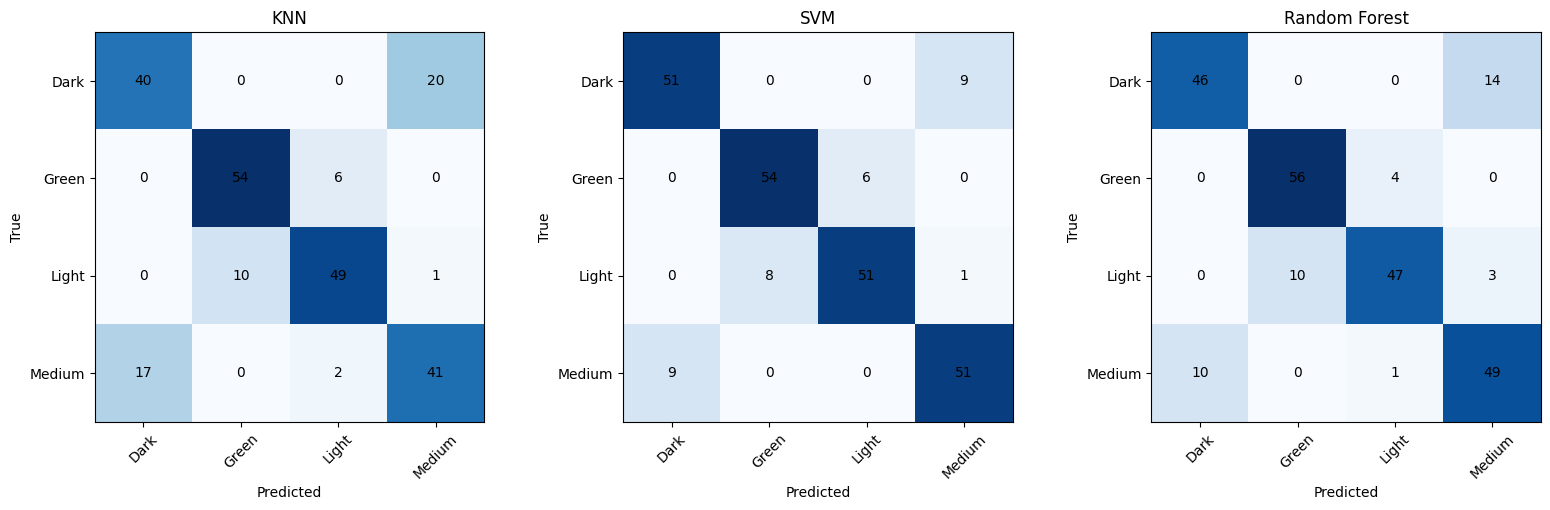

In [140]:
models_pred = {
    "KNN": y_pred_knn,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf
}

plt.figure(figsize=(16, 5))

for i, (model_name, y_pred) in enumerate(models_pred.items()):
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(1, 3, i + 1)
    plt.imshow(cm, cmap="Blues")
    plt.title(model_name)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.xticks(
        ticks=np.arange(len(label_encoder.classes_)),
        labels=label_encoder.classes_,
        rotation=45
    )
    plt.yticks(
        ticks=np.arange(len(label_encoder.classes_)),
        labels=label_encoder.classes_
    )

    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            plt.text(
                col,
                row,
                cm[row, col],
                ha="center",
                va="center",
                color="black"
            )

plt.tight_layout()
plt.show()
